<a href="https://colab.research.google.com/github/LuwamMKefali/BioMistral-VoRA-VQA-VISION-LANGUAGE-PROJECT-/blob/main/VoRA_BioMistral_VQA_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 👁️ **VoRA + BioMistral for Medical VQA**
Student: **Luwam Major Kefali**

Supervised by: **Dr. Giacomo Frisoni**
             , **Prof. Gianluca Moro**



## 📜 Outline

- [1 - Introduction: Vision as LoRA (VoRA)](#1)
  - [1.1 - Background and Motivation](#1.1)
  - [1.2 - Our Use Case: Medical VQA with BioMistral](#1.2)
- [2 - Setup](#2)
  - [2.1 - Environment and Dependencies](#2.1)
  - [2.2 - Constants and Visual Utilities](#2.2)
- [3 - Data Preparation](#3)
  - [3.1 - Pre-training Data: ROCO (Radiology Objects in Context)](#3.1)
  - [3.2 - Fine-tuning Data: VQA-RAD](#3.2)
  - [3.3 - Dataset Exploration and Visualization](#3.3)
- [4 - Model Architecture](#4)
  - [4.1 - BioMistral-7B: The Base LLM](#4.1)
  - [4.2 - VoRA Configuration and Initialization](#4.2)
  - [4.3 - Architecture Visualization and Parameter Analysis](#4.3)
- [5 - Pre-training: Injecting Vision into BioMistral](#5)
  - [5.1 - Vision Embedding Layer](#5.1)
  - [5.2 - Block-wise Distillation from ViT](#5.2)
  - [5.3 - Bi-directional Attention Masks for Vision](#5.3)
  - [5.4 - Pre-training Loop](#5.4)
- [6 - Fine-tuning on VQA-RAD](#6)
  - [6.1 - LoRA Merging and Full Model Preparation](#6.1)
  - [6.2 - VQA Dataset Wrapper](#6.2)
  - [6.3 - Fine-tuning Loop](#6.3)
- [7 - Inference and Evaluation](#7)
  - [7.1 - Qualitative Results](#7.1)
  - [7.2 - Quantitative Evaluation](#7.2)
  - [7.3 - Comparison with Encoder-based MLLMs](#7.3)
- [8 - Visualizations and Analysis](#8)
  - [8.1 - Training Loss Curves](#8.1)
  - [8.2 - Embedding Space Analysis](#8.2)
  - [8.3 - Attention Visualization](#8.3)
- [9 - Conclusion and Future Work](#9)
- [References](#refs)

</br>

**Note:** This notebook is designed to run on Google Colab with a GPU runtime (A100 recommended). To ensure a clean environment, disconnect and delete the runtime before re-running. Pre-training can be scaled to a dedicated cluster (e.g., SLURM-based) if Colab resources are insufficient.

<a name='1'></a>
# **Giving Eyes to a Blind Medical LLM: VoRA + BioMistral for Radiology VQA**

<a name='1.1'></a>
## 📖 1.1 Background and Motivation

Multimodal Large Language Models (MLLMs) have traditionally relied on a modular, encoder-based architecture: a pre-trained Vision Transformer (ViT) extracts visual features, which are then aligned with a Large Language Model (LLM) through a connector module ([Liu et al., 2024](https://arxiv.org/abs/2310.03744); [Li et al., 2023](https://arxiv.org/abs/2301.12597)). While effective, this design introduces **sequential computational overhead** (the LLM must wait for the ViT and connector to finish processing) and constrains images to the **fixed resolutions** supported by the ViT.

Recent encoder-free approaches such as Fuyu ([Bavishi et al., 2023](https://www.adept.ai/blog/fuyu-8b)) and EVE ([Diao et al., 2025](https://arxiv.org/abs/2406.11832)) attempted to bypass the external vision encoder entirely by processing raw pixels within the LLM itself. However, these methods face a fundamental challenge: **modality conflict**. Training the LLM on both visual and textual data with shared parameters often leads to unstable training dynamics and catastrophic forgetting of the model's original language capabilities.

**Vision as LoRA (VoRA)**, proposed by [Wang et al. (2025)](https://arxiv.org/abs/2503.20680), offers an elegant solution to this problem. The core idea is to internalize visual capabilities within the LLM by integrating **vision-specific LoRA layers** directly into the model's Transformer blocks. VoRA introduces three key components:

1. **Vision as LoRA.** Trainable low-rank adaptation layers are applied to the first $N_{\text{vit}}$ blocks of the LLM, encoding vision while the original LLM weights remain frozen. After training, these LoRA layers can be **merged** into the base model at near-zero inference cost.

2. **Block-wise distillation.** Visual knowledge is transferred from a pre-trained ViT teacher into the LoRA layers by aligning intermediate representations block-by-block, accelerating training and reducing data requirements.

3. **Bi-directional attention masks for vision.** Unlike the causal (left-to-right) attention used for text, image tokens attend to all other image tokens bidirectionally, capturing global spatial context.

The result is that a text-only LLM can acquire native multimodal capabilities through a small set of additional parameters, without ever requiring a separate vision encoder during inference.

The figure below (adapted from [Wang et al., 2025](https://arxiv.org/abs/2503.20680)) illustrates the key architectural difference. The left side shows the conventional encoder-based MLLM pipeline (ViT + Connector + LLM), while the right side shows VoRA's streamlined design (Embedding + LLM with LoRA).

<div align='center'>
    <img src='https://raw.githubusercontent.com/Hon-Wong/VoRA/main/assets/overview.png' width='700'/>
</div>

> **Figure 1.** High-level overview of VoRA vs. encoder-based MLLMs. In VoRA, visual parameters (LoRA layers) are merged into the LLM after training, leaving only a lightweight embedding layer as additional overhead. Source: [Wang et al., 2025](https://arxiv.org/abs/2503.20680).

<a name='1.2'></a>
## 🏥 1.2 Our Use Case: Medical VQA with BioMistral

In this notebook, I explore whether VoRA can be applied in the **biomedical domain** to give vision capabilities to a text-only medical LLM. Specifically, I aim to transform [BioMistral-7B](https://huggingface.co/BioMistral/BioMistral-7B) ([Labrak et al., 2024](https://arxiv.org/abs/2402.10373)), a Mistral-based LLM pre-trained on PubMed Central, into a multimodal model capable of **Visual Question Answering (VQA) on chest radiographs**.

This is, to my knowledge, the first attempt to apply VoRA in a medical context. The motivation is twofold:

- **Practical relevance.** Chest X-ray interpretation is one of the most common radiological tasks, and automating VQA on these images has significant clinical potential.
- **Scientific curiosity.** VoRA was validated on general-domain benchmarks; testing whether its vision-injection paradigm transfers to a specialized medical LLM is an open question.

The pipeline proceeds in two stages:

**Stage 1: Pre-training.** I use the [ROCO dataset](https://github.com/razorx89/roco-dataset) ([Pelka et al., 2018](https://arxiv.org/abs/1809.04420)), which contains ~80K radiology images paired with captions from PubMed articles. During this stage, only the LoRA layers and a lightweight visual embedding layer are trained; BioMistral's weights remain frozen. A pre-trained ViT serves as the teacher for block-wise distillation.

**Stage 2: Fine-tuning.** The LoRA layers are merged into BioMistral, and the full model is fine-tuned on [VQA-RAD](https://huggingface.co/datasets/flaviagiammarino/vqa-rad) ([Lau et al., 2018](https://arxiv.org/abs/1803.09934)), a radiology VQA benchmark with ~3,500 question-answer pairs across ~315 images (predominantly chest X-rays).

By comparing the resulting model against native multimodal medical LLMs (e.g., LLaVA-Med), I can assess whether VoRA's adapter-based approach is a viable alternative to building dedicated multimodal architectures for the medical domain.

### 🧬 Why BioMistral?

[BioMistral-7B](https://huggingface.co/BioMistral/BioMistral-7B) is a domain-adapted version of Mistral-7B, further pre-trained on biomedical text from PubMed Central. It was presented at ACL 2024 by [Labrak et al. (2024)](https://arxiv.org/abs/2402.10373) and demonstrated strong performance on medical NLP benchmarks. Critically, BioMistral is a **text-only** model with no inherent vision capabilities, making it an ideal candidate for VoRA.

If VoRA can successfully inject visual understanding into BioMistral through LoRA alone, it would confirm that the paradigm generalizes beyond the Qwen2.5-7B backbone used in the original VoRA paper, and that **medical LLMs can become multimodal with minimal architectural changes**.

### 🔬 Why ROCO for Pre-training?

The choice of pre-training data is important. The original VoRA paper used ~30M re-captioned images from DataComp-1B, which is a general-domain dataset. For our medical application, I selected the **ROCO (Radiology Objects in COntext)** dataset for several reasons:

- It contains **~80K radiology images** with natural language captions extracted from PubMed articles, providing domain-relevant visual knowledge.
- It is **publicly available** and does not require institutional credentialing (unlike MIMIC-CXR).
- Its size (~80K) is manageable for Colab-scale experiments while still providing meaningful signal for distillation.
- The image modalities span X-rays, CTs, MRIs, and ultrasounds, encouraging generalization.

For production-scale experiments, one could supplement ROCO with MIMIC-CXR (~370K chest X-rays with radiology reports, [Johnson et al., 2019](https://arxiv.org/abs/1901.07042)) or PMC-OA (biomedical image-text pairs from PubMed Central Open Access).



---



<a name='2'></a>
# **2. Setup**

<a name='2.1'></a>
## 🔧 2.1 Environment and Dependencies

Check that the Runtime type is `Python 3` with a `GPU`-based hardware accelerator (A100 40GB recommended).

Go to "Runtime" $\rightarrow$ "Change runtime type".

### 📦 Packages

We install HuggingFace Transformers, PEFT (for LoRA adapters), and other dependencies. We then clone the official [VoRA repository](https://github.com/Hon-Wong/VoRA) and install it in editable mode so we can import its model classes directly.

In [1]:
!pip uninstall -y torch_xla

In [2]:
import os

# Disabling flash attention mgiht be necessary to avoid compatibility issues on some gpus
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

os.environ["PYTORCH_SDP_DISABLE_FLASH_ATTN"] = "1"
os.environ["PYTORCH_SDP_DISABLE_MEM_EFF_ATTENTION"] = "1"
os.environ["PYTORCH_SDP_DISABLE_CUDA_SDPA"] = "1"

In [3]:
# Core ML and HuggingFace stack
!pip install -q -U transformers accelerate peft einops datasets bitsandbytes

# Image processing and visulization
!pip install -q colorlog scikit-learn seaborn

# cloning the official VoRA repo (Wnag et al., 2025)
!git clone https://github.com/Hon-Wong/VoRA.git
%pip install -q -e VoRA
%cd VoRA

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 61.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.5/527.5 kB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 45.6 MB/s eta 0:00:00
Cloning into 'VoRA'...
remote: Enumerating objects: 184, done.
remote: Counting objects: 100% (184/184), done.
remote: Compressing objects: 100% (133/133), done.
remote: Total 184 (delta 62), reused 144 (delta 40), pack-reused 0 (from 0)
Receiving objects: 100% (184/184), 9.30 MiB | 21.29 MiB/s, done.
Resolving deltas: 100% (62/62), done.
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 9.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━

After running the above, we see the packages being installed and the VoRA repository cloned.
The VoRA repo contains the implementation of the approach described in Han et al. (2025), including
model classes and training utilities.


*   **VoRA** repository code will give us VoRAForCausalLM- a model wrapper that integrated an LLM with vision embedding and LoRA, as per the VoRA architecture





In [3]:
import sys
sys.path.append("/content/VoRA")
print(sys.path)

['/content', '/env/python', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/usr/local/lib/python3.12/dist-packages', '__editable__.vora-0.1.0.finder.__path_hook__', '/usr/lib/python3/dist-packages', '/usr/local/lib/python3.12/dist-packages/IPython/extensions', '/root/.ipython', '/usr/local/lib/python3.12/dist-packages/setuptools/_vendor', '/content/VoRA']


VQA-RAD is a relatively small dataset in the medical domain, which underscores the importance of
**transfer learning** for this we rely on BioMistral’s prior knowledge of medical text and VoRA’s visual prior
injection to make the most of this limited data. Each question in VQA-RAD is directly related to an image
(e.g., *“Are regions of the brain infarcted?”* referring to a brain MRI, with answer *“yes”*). The questions can
be about identifying findings, counting, or verifying the presence of certain anomalies in the image.
This variety makes it a good testbed for a multimodal medical model, albeit on a small scale.

### 🧱 Import Core Libraries and VoRA Modules

We set up imports for:
- HuggingFace tools (tokenizer, model, PEFT LoRA)
- Torch and torchvision
- Custom VoRA model classes (`VoRAForCausalLM`, `VoRAConfig`)
- Utilities for data loading and vision preprocessing

We also register the VoRA repo path so we can import its modules.

References: (Han et al., 2025)


In [4]:
import sys
import json
import math
import warnings
from pathlib import Path
from dataclasses import dataclass, field
from typing import Optional, Dict, List, Tuple

# Numerical and data
import numpy as np
import pandas as pd

# Deep learning
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Vision
from PIL import Image
from torchvision import transforms

# HuggingFace
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModel,
    AutoImageProcessor,
    BitsAndBytesConfig,
)
from peft import get_peft_model, LoraConfig, TaskType
from datasets import load_dataset, load_from_disk

# Plotting
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Suppress non-critical warnings for cleaner output
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.5.1+cu124
CUDA available: True


In [5]:
# VoRA modules (Wang et al., 2025)
# These require the VoRA repo to be cloned and installed from the cells above
sys.path.insert(0, os.getcwd())
from models.modeling_vora import VoRAForCausalLM
from models.configuration_vora import VoRAConfig
from train.train import VoRATrainer, TrainingArguments

print("VoRA modules loaded successfully.")

VoRA modules loaded successfully.


### 🖥️ Hardware Check

VoRA pre-training with BioMistral-7B requires a GPU with at least 40GB of VRAM. On Colab, an A100 is recommended. For full training, a multi-GPU cluster is preferable.

In [7]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9  # "total_memory" not "total_mem"
    print(f"GPU: {gpu_name}")
    print(f"VRAM: {gpu_mem:.1f} GB")
    print(f"CUDA version: {torch.version.cuda}")
else:
    device = torch.device("cpu")
    print("WARNING: No GPU detected. Training will be extremely slow.")

print(f"\nUsing device: {device}")

GPU: Tesla T4
VRAM: 15.6 GB
CUDA version: 12.4

Using device: cuda


<a name='2.2'></a>
## 🎨 2.2 Constants and Visual Utilities

This cell defines reusable constants and plotting functions used throughout the notebook. I follow a consistent visual style to keep figures clean and informative.

In [8]:
# Global Constants
IMAGE_SIZE = 448                       # VoRA default image resolution
PATCH_SIZE = 14                        # Patch size for vision embedding
NUM_PATCHES = (IMAGE_SIZE // PATCH_SIZE) ** 2  # 1024 patches per image
LLM_NAME = "BioMistral/BioMistral-7B" # Base LLM backbone
VIT_TEACHER = "apple/aimv2-huge-patch14-448"  # ViT teacher for distillation
LORA_RANK = 128                        # LoRA rank (lower than paper's 1024 for memory)
SEED = 42                              # Reproducibility

# Output directories
OUTPUT_DIR_PRETRAIN = "./checkpoints/vora_biomistral_pretrain"
OUTPUT_DIR_FINETUNE = "./checkpoints/vora_biomistral_finetune"

# seeds for reproducibility
torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"Image size: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"Patches per image: {NUM_PATCHES}")
print(f"Base LLM: {LLM_NAME}")
print(f"ViT teacher: {VIT_TEACHER}")
print(f"LoRA rank: {LORA_RANK}")

Image size: 448x448
Patches per image: 1024
Base LLM: BioMistral/BioMistral-7B
ViT teacher: apple/aimv2-huge-patch14-448
LoRA rank: 128


In [9]:
# plot Style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
FIGSIZE_WIDE = (12, 5)
FIGSIZE_SQUARE = (7, 7)
FIGSIZE_TALL = (8, 10)
CMAP_DIVERGING = "coolwarm"
CMAP_SEQUENTIAL = "viridis"


def plot_image_grid(images, titles=None, ncols=4, figsize=(14, 4)):
    """
    Display a grid of PIL images with optional titles.
    Usedfor previewing dataset samples.
    """
    nrows = math.ceil(len(images) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.atleast_2d(axes)
    for idx, ax in enumerate(axes.flat):
        if idx < len(images):
            ax.imshow(images[idx], cmap="gray" if images[idx].mode == "L" else None)
            if titles:
                ax.set_title(titles[idx], fontsize=9, wrap=True)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


def plot_loss_curves(train_losses, val_losses=None, title="Training Loss"):
    """
    Plot training and validation) loss curves.
    """
    fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
    steps = range(1, len(train_losses) + 1)
    ax.plot(steps, train_losses, label="Train", linewidth=2)
    if val_losses is not None:
        ax.plot(range(1, len(val_losses) + 1), val_losses, label="Val", linewidth=2, linestyle="--")
    ax.set_xlabel("Step")
    ax.set_ylabel("Loss")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_embedding_space(embeddings, labels, label_names=None, method="tsne", title="Embedding Space"):
    """
    Project high-dimensional embeddings to 2D using t-SNE or PCA
    and visualize with color-coded labels.
    """
    if method == "tsne":
        reducer = TSNE(n_components=2, random_state=SEED, perplexity=min(30, len(embeddings) - 1))
    else:
        reducer = PCA(n_components=2)
    coords = reducer.fit_transform(embeddings)

    fig, ax = plt.subplots(figsize=FIGSIZE_SQUARE)
    unique_labels = sorted(set(labels))
    colors = sns.color_palette("husl", len(unique_labels))
    for i, label in enumerate(unique_labels):
        mask = [l == label for l in labels]
        name = label_names[i] if label_names else str(label)
        ax.scatter(coords[mask, 0], coords[mask, 1], c=[colors[i]], label=name, alpha=0.7, s=30)
    ax.legend(markerscale=2)
    ax.set_title(title)
    ax.set_xlabel("Dim 1")
    ax.set_ylabel("Dim 2")
    plt.tight_layout()
    plt.show()


def plot_attention_heatmap(attn_weights, x_labels, y_labels, title="Attention Weights"):
    """
    Plot an attention heatmap for a single head or averaged heads.
    """
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(attn_weights, xticklabels=x_labels, yticklabels=y_labels,
                cmap=CMAP_SEQUENTIAL, ax=ax, square=True)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def count_parameters(model):
    """
    Count and print total vs. trainable parameters in a model.
    Returns (total, trainable) tuple.
    """
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen = total - trainable
    print(f"Total parameters:     {total / 1e6:>10.1f}M")
    print(f"Trainable parameters: {trainable / 1e6:>10.1f}M ({100 * trainable / total:.2f}%)")
    print(f"Frozen parameters:    {frozen / 1e6:>10.1f}M ({100 * frozen / total:.2f}%)")
    return total, trainable


print("Utilities loaded.")

Utilities loaded.


### 🖼️ Image Preprocessing

VoRA processes images as raw pixel tensors passed through a lightweight embedding layer (a shallow MLP with positional encodings, approximately 6M parameters). The image is resized to a fixed resolution and normalized using ImageNet statistics, consistent with the ViT teacher model ([Wang et al., 2025](https://arxiv.org/abs/2503.20680), Sec. 3.1).

In [10]:
# Standard preprocessing pipeline for VoRA
# Matches the normalization used by the ViT teacher (AIMv2)
vision_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],  # ImageNet statistics
        std=[0.229, 0.224, 0.225]
    ),
])


def preprocess_image(image: Image.Image) -> torch.Tensor:
    """
    Convert a PIL image to a normalized tensor suitable for VoRA.
    Returns shape: [1, 3, IMAGE_SIZE, IMAGE_SIZE]
    """
    if image.mode != "RGB":
        image = image.convert("RGB")
    return vision_transform(image).unsqueeze(0)


print(f"Image preprocessing configured: resize to {IMAGE_SIZE}x{IMAGE_SIZE}, ImageNet normalization.")

Image preprocessing configured: resize to 448x448, ImageNet normalization.




---



<a name='3'></a>
# **3. Data Preparation**

VoRA's pipeline requires data for two distinct stages. In **pre-training**, we need image-caption pairs to inject visual understanding into BioMistral via LoRA layers and block-wise distillation. In **fine-tuning**, we need task-specific data (image + question + answer) to adapt the model for Visual Question Answering.

Following the VoRA paper's approach ([Wang et al., 2025](https://arxiv.org/abs/2503.20680), Sec. 4), we also mix in a small portion of text-only instruction data during pre-training to prevent degradation of the LLM's instruction-following capability.

<a name='3.1'></a>
## 📥 3.1 Pre-training Data: ROCO (Radiology Objects in Context)

The [ROCO dataset](https://github.com/razorx89/roco-dataset) ([Pelka et al., 2018](https://arxiv.org/abs/1809.04420)) is a large-scale medical image-caption dataset containing radiology figures extracted from PubMed Open Access articles. Each sample consists of a medical image (X-ray, CT, MRI, ultrasound, etc.) paired with its original figure caption.

Key statistics:
- **~81K images** across training, validation, and test splits
- Captions are natural language descriptions from scientific publications
- Covers multiple imaging modalities and anatomical regions

This dataset serves as our source of medical visual knowledge. During pre-training, the ViT teacher will extract visual features from these images, and the LoRA layers will learn to reproduce those features block-by-block within BioMistral, while the language modeling head learns to generate the captions.

In [11]:
# download the ROCO dataset from HuggingFace
# This contains radiology images paired with captions from PubMed articles
roco_dataset = load_dataset("eltorio/ROCO-radiology")

print("ROCO dataset structure:")
print(roco_dataset)
print(f"\nTraining samples: {len(roco_dataset['train']):,}")
print(f"Validation samples: {len(roco_dataset['validation']):,}")
print(f"Test samples: {len(roco_dataset['test']):,}")

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/26 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/26 [00:00<?, ?it/s]

data/train-00000-of-00026.parquet:   0%|          | 0.00/498M [00:00<?, ?B/s]

data/train-00001-of-00026.parquet:   0%|          | 0.00/486M [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/65423 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/8175 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/8176 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/26 [00:00<?, ?it/s]

ROCO dataset structure:
DatasetDict({
    train: Dataset({
        features: ['image', 'image_id', 'caption'],
        num_rows: 65423
    })
    validation: Dataset({
        features: ['image', 'image_id', 'caption'],
        num_rows: 8175
    })
    test: Dataset({
        features: ['image', 'image_id', 'caption'],
        num_rows: 8176
    })
})

Training samples: 65,423
Validation samples: 8,175
Test samples: 8,176


In [13]:
# Inspect a single sample to understand the data format
sample = roco_dataset["train"][0]
print("Keys:", list(sample.keys()))
print(f"\nCaption: {sample['caption']}")
print(f"Image type: {type(sample['image'])}")
print(f"Image size: {sample['image'].size}")
print(f"Image mode: {sample['image'].mode}")

Keys: ['image', 'image_id', 'caption']

Caption:  Computed tomography scan in axial view showing obliteration of the left maxillary sinus

Image type: <class 'PIL.PngImagePlugin.PngImageFile'>
Image size: (704, 704)
Image mode: RGB


### 👁️ Preview: ROCO Training Samples

Let's visualize a few samples from the ROCO training set to get a sense of the image modalities and caption quality. Note the diversity: we expect to see X-rays, CT slices, MRI scans, and other radiology figures alongside their scientific captions.

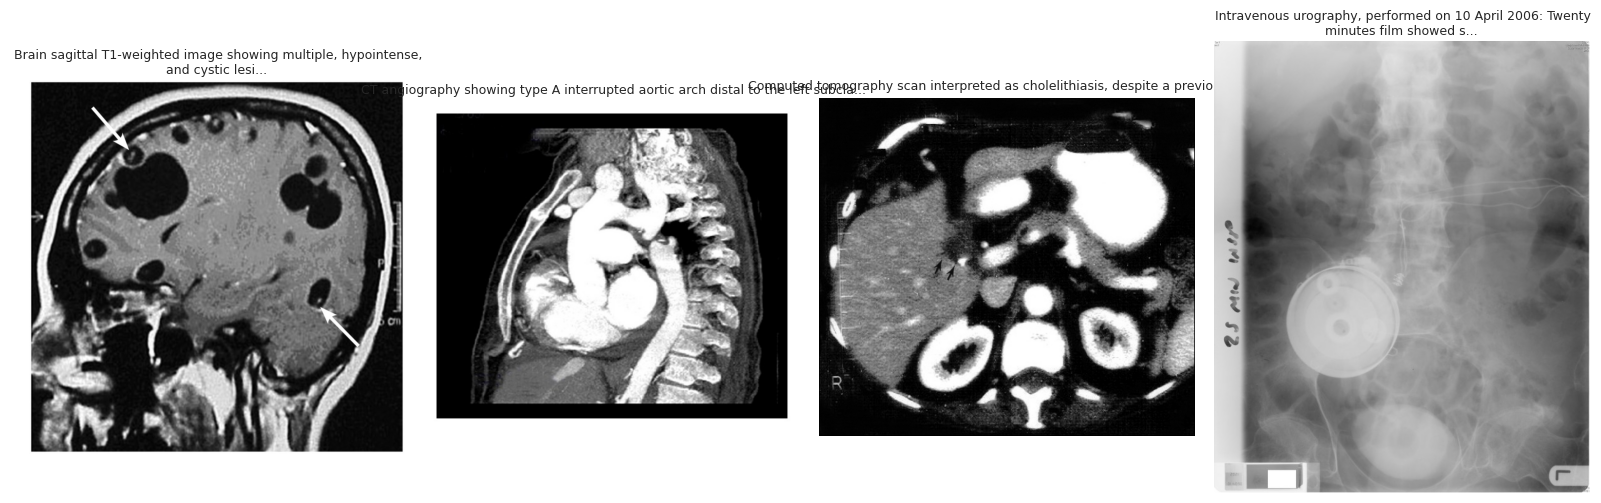

In [15]:
# VIsualize 8 random samples from the ROCO training set
rng = np.random.RandomState(SEED)
sample_indices = rng.choice(len(roco_dataset["train"]), size=4, replace=False)

preview_images = []
preview_titles = []
for idx in sample_indices:
    s = roco_dataset["train"][int(idx)]
    img = s["image"]
    if img.mode != "RGB":
        img = img.convert("RGB")
    preview_images.append(img)
    # Truncate long captions for display
    caption = s["caption"]
    short_caption = caption[:80] + "..." if len(caption) > 80 else caption
    preview_titles.append(short_caption)

plot_image_grid(preview_images, titles=preview_titles, ncols=4, figsize=(16, 8))

### 📊 ROCO Caption Length Distribution

Understanding the distribution of caption lengths helps us set appropriate tokenization parameters (e.g., `max_length`) during pre-training. Medical captions from PubMed tend to be longer and more technical than general-domain captions.

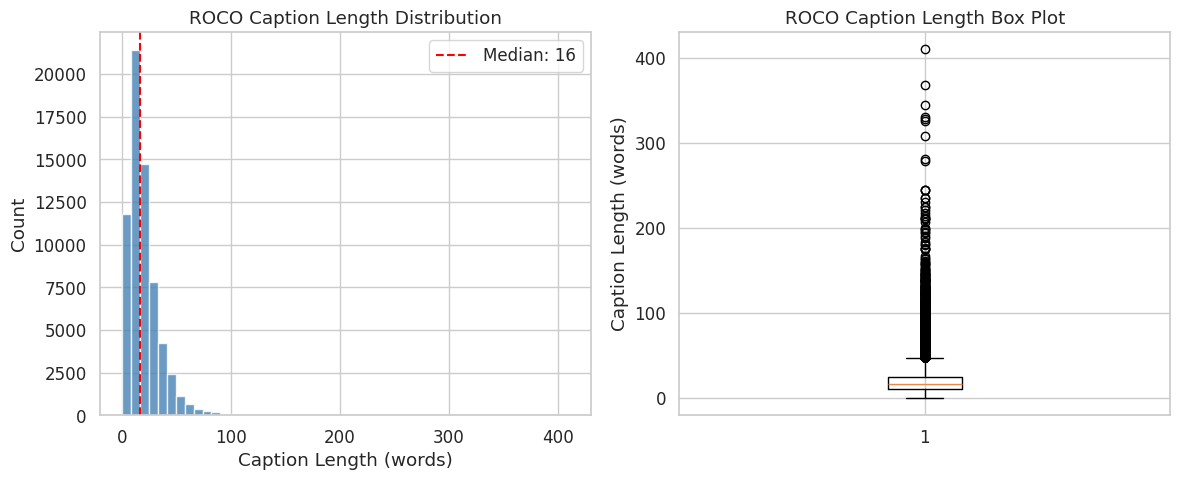

Caption length stats:
  Min:    0
  Max:    410
  Mean:   20.2
  Median: 16


In [16]:
# Compute caption lengths (in words) for the training split
caption_lengths = [len(s["caption"].split()) for s in roco_dataset["train"]]

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)

# Histogram
axes[0].hist(caption_lengths, bins=50, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].set_xlabel("Caption Length (words)")
axes[0].set_ylabel("Count")
axes[0].set_title("ROCO Caption Length Distribution")
axes[0].axvline(np.median(caption_lengths), color="red", linestyle="--", label=f"Median: {np.median(caption_lengths):.0f}")
axes[0].legend()

# Box plot
axes[1].boxplot(caption_lengths, vert=True)
axes[1].set_ylabel("Caption Length (words)")
axes[1].set_title("ROCO Caption Length Box Plot")

plt.tight_layout()
plt.show()

print(f"Caption length stats:")
print(f"  Min:    {min(caption_lengths)}")
print(f"  Max:    {max(caption_lengths)}")
print(f"  Mean:   {np.mean(caption_lengths):.1f}")
print(f"  Median: {np.median(caption_lengths):.0f}")

### 📊 ROCO Image Size Distribution

We also examine the raw image dimensions before resizing. VoRA resizes all images to a fixed $448 \times 448$ resolution, so it is useful to know the original aspect ratios and whether significant information loss occurs during resizing.

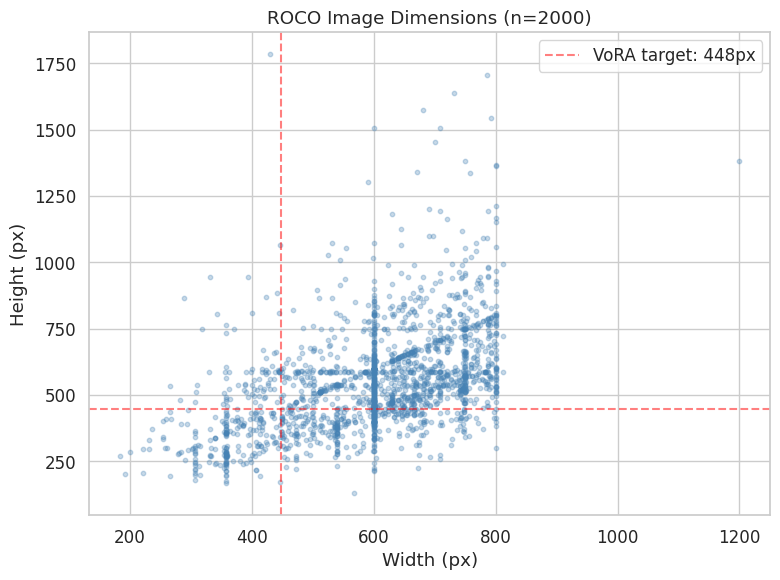

Width  - Mean: 600, Median: 600
Height - Mean: 547, Median: 532


In [17]:
# Sample a subset to compute image dimensions(avoids iterating over the whole datset)
n_sample = min(2000, len(roco_dataset["train"]))
size_indices = rng.choice(len(roco_dataset["train"]), size=n_sample, replace=False)

widths, heights = [], []
for idx in size_indices:
    img = roco_dataset["train"][int(idx)]["image"]
    w, h = img.size
    widths.append(w)
    heights.append(h)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(widths, heights, alpha=0.3, s=10, c="steelblue")
ax.set_xlabel("Width (px)")
ax.set_ylabel("Height (px)")
ax.set_title(f"ROCO Image Dimensions (n={n_sample})")
ax.axhline(IMAGE_SIZE, color="red", linestyle="--", alpha=0.5, label=f"VoRA target: {IMAGE_SIZE}px")
ax.axvline(IMAGE_SIZE, color="red", linestyle="--", alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()

print(f"Width  - Mean: {np.mean(widths):.0f}, Median: {np.median(widths):.0f}")
print(f"Height - Mean: {np.mean(heights):.0f}, Median: {np.median(heights):.0f}")

<a name='3.2'></a>
## 📥 3.2 Fine-tuning Data: VQA-RAD

The [VQA-RAD dataset](https://huggingface.co/datasets/flaviagiammarino/vqa-rad) ([Lau et al., 2018](https://arxiv.org/abs/1803.09934)) is a radiology Visual Question Answering benchmark specifically designed for evaluating multimodal medical AI. It contains question-answer pairs grounded in radiology images, predominantly chest X-rays.

Key statistics:
- **~1793 QA pairs** across ~315 unique radiology images
- Questions range from binary (yes/no) to open-ended (free-form answers)
- Image modalities include chest X-rays, brain MRIs, and abdominal CTs

This is the standard benchmark for medical VQA, which allows us to compare our VoRA-based approach against published results from dedicated multimodal models such as LLaVA-Med.

In [18]:
# Download VQA-RAD from HuggingFace
vqa_dataset = load_dataset("flaviagiammarino/vqa-rad")

print("VQA-RAD dataset structure:")
print(vqa_dataset)
print(f"\nTraining samples: {len(vqa_dataset['train']):,}")
print(f"Test samples: {len(vqa_dataset['test']):,}")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-eb8844602202be(…):   0%|          | 0.00/24.2M [00:00<?, ?B/s]

data/test-00000-of-00001-e5bc3d208bb4dee(…):   0%|          | 0.00/10.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1793 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/451 [00:00<?, ? examples/s]

VQA-RAD dataset structure:
DatasetDict({
    train: Dataset({
        features: ['image', 'question', 'answer'],
        num_rows: 1793
    })
    test: Dataset({
        features: ['image', 'question', 'answer'],
        num_rows: 451
    })
})

Training samples: 1,793
Test samples: 451


In [19]:
# Inspect the structure of a single VQA-RAD sample
sample = vqa_dataset["train"][0]
print("Keys:", list(sample.keys()))
print(f"\nQuestion: {sample['question']}")
print(f"Answer:   {sample['answer']}")
print(f"Image type: {type(sample['image'])}")
print(f"Image size: {sample['image'].size}")

Keys: ['image', 'question', 'answer']

Question: are regions of the brain infarcted?
Answer:   yes
Image type: <class 'PIL.JpegImagePlugin.JpegImageFile'>
Image size: (566, 555)


### 👁️ Preview: VQA-RAD Training Samples

Each VQA-RAD sample contains a radiology image, a clinical question, and a ground-truth answer. Let's visualize several examples to understand the diversity of questions and the visual content the model must interpret.

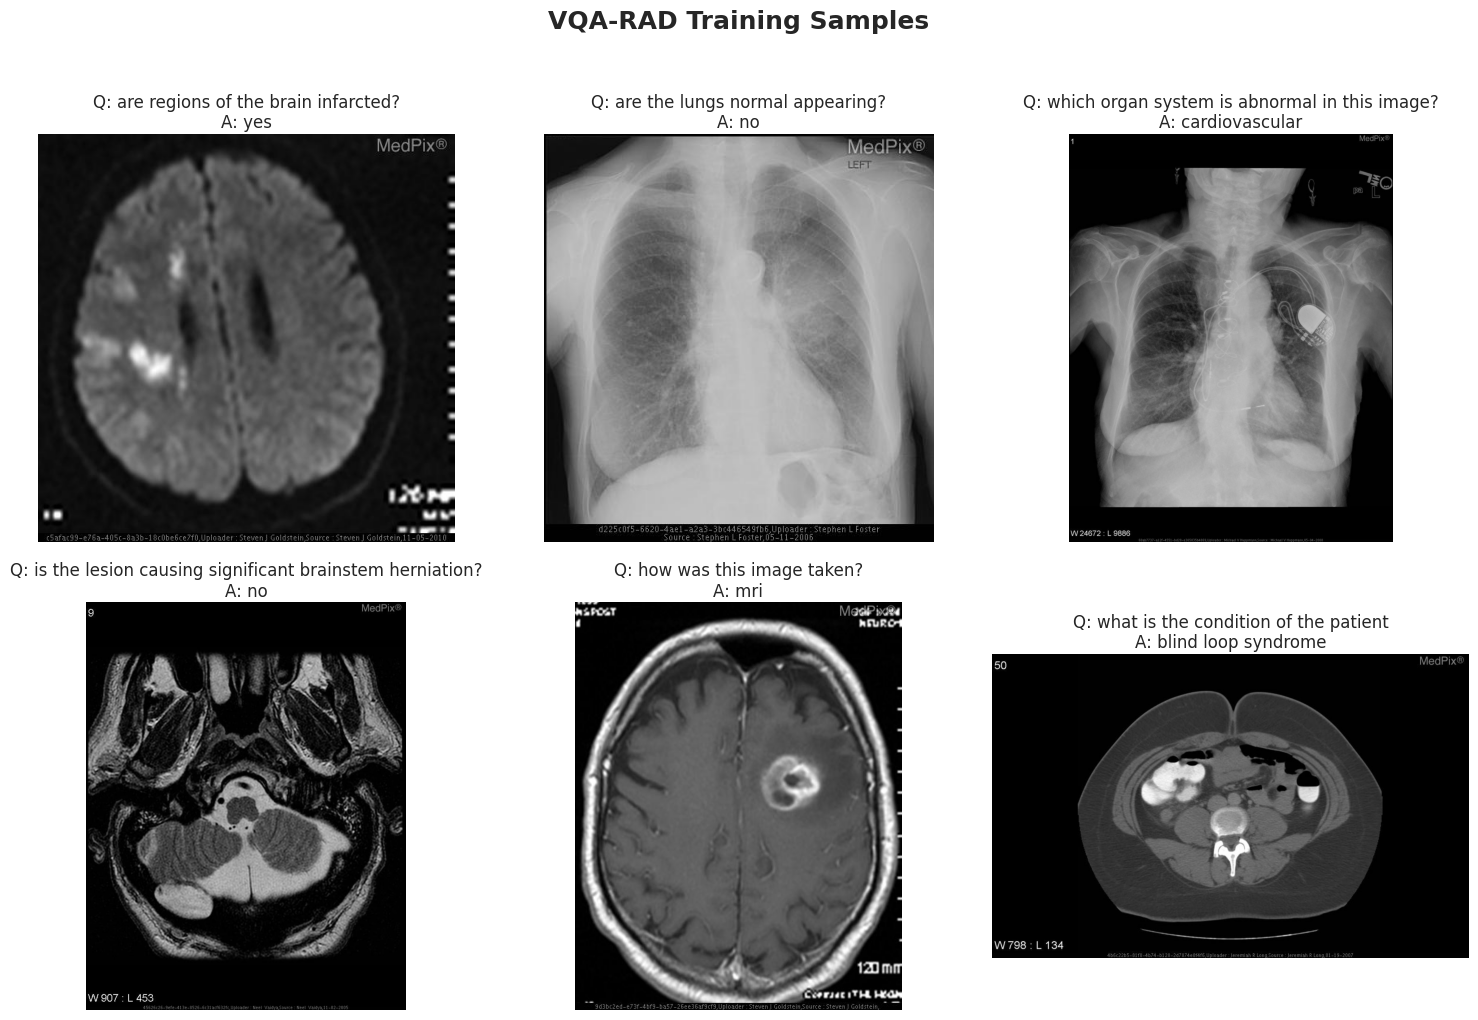

In [27]:
# Visualize 6 VQA-RAD training samples with their Q&A pairs
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for idx, ax in enumerate(axes.flat):
    s = vqa_dataset["train"][idx]
    img = s["image"]
    if img.mode != "RGB":
        img = img.convert("RGB")
    ax.imshow(img, cmap="gray")
    # Format the Q&A as the title
    q = s["question"]
    a = s["answer"]
    q_short = q[:60] + "..." if len(q) > 60 else q
    a_short = a[:40] + "..." if len(a) > 40 else a
    ax.set_title(f"Q: {q_short}\nA: {a_short}", fontsize=12, wrap=True)
    ax.axis("off")

plt.suptitle("VQA-RAD Training Samples", fontsize=18, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

<a name='3.3'></a>
## 📊 3.3 Dataset Exploration and Visualization

Before training,it is important to understand the composition of VQA-RAD. I examine the distribution of answer types (open vs. closed), answer frequencies, and question lengths. This informs design decisions such as loss weighting and evaluation metrics.

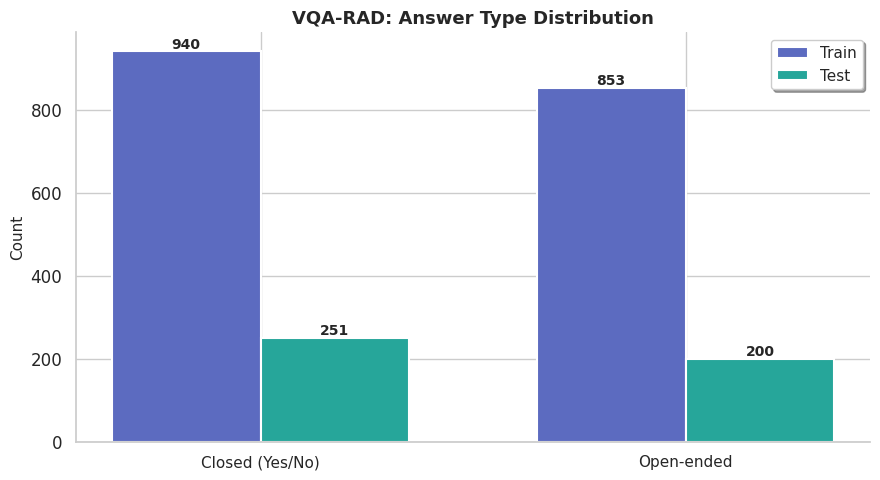

Train: {'Closed (Yes/No)': 940, 'Open-ended': 853}
Test:  {'Closed (Yes/No)': 251, 'Open-ended': 200}


In [43]:
# Analyze answer types: closed (yes/no) vs. open-ended
train_df = pd.DataFrame(vqa_dataset["train"])
test_df = pd.DataFrame(vqa_dataset["test"])

def classify_answer(ans):
    ans_lower = ans.strip().lower()
    if ans_lower in ["yes", "no"]:
        return "Closed (Yes/No)"
    return "Open-ended"

train_df["answer_type"] = train_df["answer"].apply(classify_answer)
test_df["answer_type"] = test_df["answer"].apply(classify_answer)

counts_train = train_df["answer_type"].value_counts()
counts_test = test_df["answer_type"].value_counts()

# grouped bar chart
categories = ["Closed (Yes/No)", "Open-ended"]
train_vals = [counts_train.get(c, 0) for c in categories]
test_vals = [counts_test.get(c, 0) for c in categories]

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

bars1 = ax.bar(x - width/2, train_vals, width, label="Train",
               color="#5C6BC0", edgecolor="white", linewidth=1.5)
bars2 = ax.bar(x + width/2, test_vals, width, label="Test",
               color="#26A69A", edgecolor="white", linewidth=1.5)

ax.set_ylabel("Count", fontsize=11)
ax.set_title("VQA-RAD: Answer Type Distribution", fontweight="bold", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=11)
ax.legend(fontsize=11, frameon=True, fancybox=True, shadow=True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Add value labels on top of each bar
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 8,
                str(int(h)), ha="center", fontweight="bold", fontsize=10)

plt.tight_layout()
plt.show()

print(f"Train: {counts_train.to_dict()}")
print(f"Test:  {counts_test.to_dict()}")

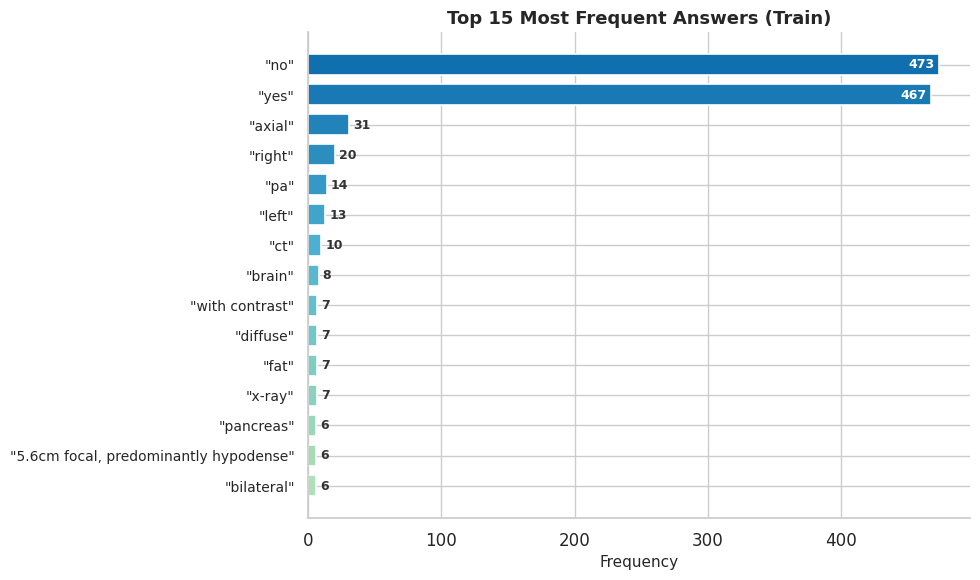

In [44]:
# Top 15 most frequent answers in the training set
top_answers = train_df["answer"].str.lower().value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))

# Color bars by frequency using a gradient
colors = plt.cm.GnBu(np.linspace(0.35, 0.85, len(top_answers)))[::-1]

bars = ax.barh(range(len(top_answers)), top_answers.values,
               color=colors, edgecolor="white", linewidth=1.2, height=0.7)

ax.set_yticks(range(len(top_answers)))
ax.set_yticklabels([f'"{a}"' for a in top_answers.index], fontsize=10)
ax.invert_yaxis()
ax.set_xlabel("Frequency", fontsize=11)
ax.set_title("Top 15 Most Frequent Answers (Train)", fontweight="bold", fontsize=13)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar, val in zip(bars, top_answers.values):
    x_pos = bar.get_width() - 3 if bar.get_width() > 40 else bar.get_width() + 3
    color = "white" if bar.get_width() > 40 else "#333333"
    ha = "right" if bar.get_width() > 40 else "left"
    ax.text(x_pos, bar.get_y() + bar.get_height() / 2,
            str(val), va="center", ha=ha, fontweight="bold", fontsize=9, color=color)

plt.tight_layout()
plt.show()

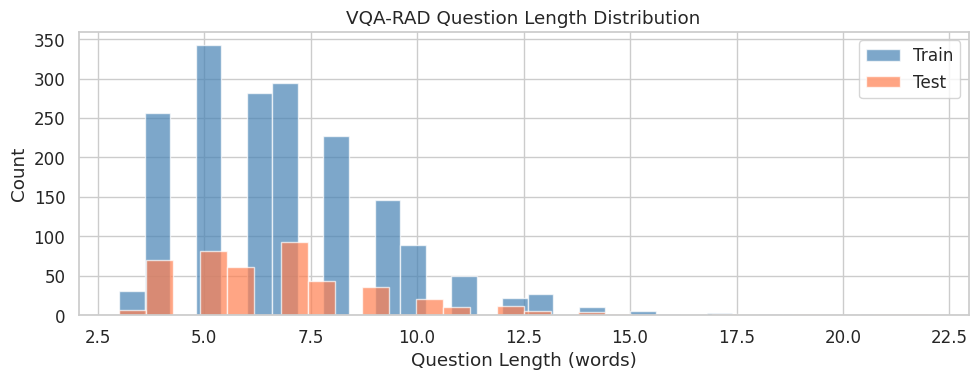

Train question length - Mean: 6.8, Median: 6
Test question length  - Mean: 6.9, Median: 7


In [23]:
# Question length distribution (in words)
train_q_lengths = train_df["question"].str.split().str.len()
test_q_lengths = test_df["question"].str.split().str.len()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(train_q_lengths, bins=30, alpha=0.7, label="Train", color="steelblue", edgecolor="white")
ax.hist(test_q_lengths, bins=30, alpha=0.7, label="Test", color="coral", edgecolor="white")
ax.set_xlabel("Question Length (words)")
ax.set_ylabel("Count")
ax.set_title("VQA-RAD Question Length Distribution")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Train question length - Mean: {train_q_lengths.mean():.1f}, Median: {train_q_lengths.median():.0f}")
print(f"Test question length  - Mean: {test_q_lengths.mean():.1f}, Median: {test_q_lengths.median():.0f}")

### 📊 Summary of Data Statistics

| Dataset | Split | Samples | Purpose |
|---------|-------|---------|---------|
| **ROCO** | Train | 65,423 | Pre-training: image-caption pairs for block-wise distillation |
| **ROCO** | Val | 8,175 | Pre-training: validation monitoring |
| **ROCO** | Test | 8,176 | Pre-training: held-out evaluation |
| **VQA-RAD** | Train | 1,793 | Fine-tuning: radiology VQA |
| **VQA-RAD** | Test | 451 | Evaluation: radiology VQA |

Note that ROCO is orders of magnitude smaller than the 30M image-caption pairs used in the original VoRA paper. This is a deliberate trade-off: we operate in a low-resource medical domain where large-scale re-captioned datasets are not freely available. The block-wise distillation mechanism in VoRA is specifically designed to accelerate training and reduce data requirements ([Wang et al., 2025](https://arxiv.org/abs/2503.20680), Sec. 5.2), so we rely on this property heavily in our setting.

VQA-RAD is also notably small (1,793 training samples), with a roughly balanced split between closed-form yes/no questions (52%) and open-ended questions (48%). This makes transfer learning from both BioMistral's medical text knowledge and VoRA's visual distillation especially critical.

### 💾 Save Datasets Locally

We save both datasets to disk so we do not need to re-download them if the runtime restarts.

In [24]:
# Save datasets locally so that we dont lose them when runtime retarts
os.makedirs("data", exist_ok=True)

roco_dataset.save_to_disk("data/roco")
vqa_dataset.save_to_disk("data/vqa_rad")

print("Datasets saved to ./data/roco and ./data/vqa_rad")

Saving the dataset (0/26 shards):   0%|          | 0/65423 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/8175 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/8176 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1793 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/451 [00:00<?, ? examples/s]

Datasets saved to ./data/roco and ./data/vqa_rad


> **Reload tip:** If the runtime restarts, reload the datasets without re-downloading:
> ```python
> roco_dataset = load_from_disk("data/roco")
> vqa_dataset = load_from_disk("data/vqa_rad")
> ```



---



<a name='4'></a>
# **4. Model Architecture**

In this section, we build the VoRA-augmented BioMistral model step by step. The process involves:

1. Loading the BioMistral-7B tokenizer and adding a special `<image>` token
2. Configuring VoRA (LoRA rank, vision embedding, attention mask type, distillation targets)
3. Instantiating `VoRAForCausalLM`, which internally loads BioMistral with frozen weights and attaches trainable LoRA layers plus a lightweight vision embedding module
4. Verifying the architecture and inspecting the trainable vs. frozen parameter breakdown

This mirrors the architecture shown in Figure 2 of [Wang et al. (2025)](https://arxiv.org/abs/2503.20680): during pre-training, only the LoRA layers and the visual embedding layer (~6M parameters) are unfrozen. The base LLM remains entirely frozen, decoupling vision and language parameters to prevent catastrophic forgetting.

<a name='4.1'></a>
## 🧠 4.1 BioMistral-7B: The Base LLM

[BioMistral-7B](https://huggingface.co/BioMistral/BioMistral-7B) ([Labrak et al., 2024](https://arxiv.org/abs/2402.10373)) is built on the Mistral-7B architecture and further pre-trained on PubMed Central articles. It uses a SentencePiece tokenizer with a vocabulary of 32,000 tokens.

We first load the tokenizer and add a special `<image>` token. This token will serve as a placeholder in the input sequence to indicate where visual embeddings should be injected. Adding it before model initialization ensures the embedding matrix is properly resized.

In [28]:
# Load the BioMistral tokenizer
tokenizer = AutoTokenizer.from_pretrained(LLM_NAME, trust_remote_code=True)

# Add a special <image> token to mark where visual embeddings are inserted
tokenizer.add_special_tokens({"additional_special_tokens": ["<image>"]})

# Set pad token to eos token (mistral doesnot define one by default)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id

# Verify the <image> token was added correctly
image_token_id = tokenizer.convert_tokens_to_ids("<image>")
assert image_token_id != tokenizer.unk_token_id, "<image> token was not added properly!"

print(f"Tokenizer vocabulary size: {len(tokenizer):,}")
print(f"<image> token ID: {image_token_id}")
print(f"Pad token: '{tokenizer.pad_token}' (ID: {tokenizer.pad_token_id})")
print(f"EOS token: '{tokenizer.eos_token}' (ID: {tokenizer.eos_token_id})")
print(f"BOS token: '{tokenizer.bos_token}' (ID: {tokenizer.bos_token_id})")

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/72.0 [00:00<?, ?B/s]

[INFO|tokenization_utils_base.py:2060] 2026-03-10 22:53:18,384 >> loading file tokenizer.model from cache at /root/.cache/huggingface/hub/models--BioMistral--BioMistral-7B/snapshots/9a11e1ffa817c211cbb52ee1fb312dc6b61b40a5/tokenizer.model
[INFO|tokenization_utils_base.py:2060] 2026-03-10 22:53:18,385 >> loading file tokenizer.json from cache at /root/.cache/huggingface/hub/models--BioMistral--BioMistral-7B/snapshots/9a11e1ffa817c211cbb52ee1fb312dc6b61b40a5/tokenizer.json
[INFO|tokenization_utils_base.py:2060] 2026-03-10 22:53:18,386 >> loading file added_tokens.json from cache at None
[INFO|tokenization_utils_base.py:2060] 2026-03-10 22:53:18,387 >> loading file special_tokens_map.json from cache at /root/.cache/huggingface/hub/models--BioMistral--BioMistral-7B/snapshots/9a11e1ffa817c211cbb52ee1fb312dc6b61b40a5/special_tokens_map.json
[INFO|tokenization_utils_base.py:2060] 2026-03-10 22:53:18,388 >> loading file tokenizer_config.json from cache at /root/.cache/huggingface/hub/models--B

Tokenizer vocabulary size: 32,001
<image> token ID: 32000
Pad token: '</s>' (ID: 2)
EOS token: '</s>' (ID: 2)
BOS token: '<s>' (ID: 1)


<a name='4.2'></a>
## ⚙️ 4.2 VoRA Configuration and Initialization

The `VoRAConfig` class (from the official VoRA repository) bundles together all the architectural choices. Here I set the key hyperparameters:

- **`llm`**: The base LLM identifier (BioMistral-7B)
- **`image_size` / `patch_size`**: Input resolution (448) and patch size (14), yielding $32 \times 32 = 1024$ visual tokens per image
- **`vision_embedding`**: The type of embedding layer. `AIMv2Embedding` is a shallow MLP with 2D positional encodings (~6M parameters), as described in [Wang et al. (2025)](https://arxiv.org/abs/2503.20680), Sec. 3.1
- **`vision_attention_mask`**: Set to `bidirectional` so image tokens attend to all other image tokens, while text tokens retain causal masking (Sec. 3.3)
- **`lora.r`**: The LoRA rank. The paper uses 1024 (~2B trainable parameters); I use 128 here to fit on Colab. This can be scaled up on a dedicated cluster
- **`lora.target_modules`**: LoRA is applied to all linear layers in the attention and FFN blocks of the first $N_{\text{vit}}$ LLM layers

In [29]:
# Configure VoRA for BioMistral-7B
vora_config = VoRAConfig(
    llm=LLM_NAME,
    image_size=IMAGE_SIZE,
    patch_size=PATCH_SIZE,
    vision_embedding="AIMv2Embedding",
    vision_embedding_intermediate_size=768,      # intermediate dim of the MLP embedding
    vision_attention_mask="bidirectional",        # Bidirectional attention for image tokens
    rms_norm_eps=1e-6,
    lora={
        "r": LORA_RANK,
        "target_modules": [
            "self_attn.q_proj",
            "self_attn.k_proj",
            "self_attn.v_proj",
            "self_attn.o_proj",
            "mlp.gate_proj",
            "mlp.up_proj",
            "mlp.down_proj",
        ],
        "lora_alpha": LORA_RANK,                 # Alpha = rank is a common default
        "lora_dropout": 0.05,
    },
)

print("VoRA configuration created:")
print(f"  Base LLM:           {vora_config.llm}")
print(f"  Image size:         {vora_config.image_size}")
print(f"  Patch size:         {vora_config.patch_size}")
print(f"  Vision embedding:   {vora_config.vision_embedding}")
print(f"  Attention mask:     {vora_config.vision_attention_mask}")
print(f"  LoRA rank:          {vora_config.lora['r']}")
print(f"  LoRA targets:       {vora_config.lora['target_modules']}")

VoRA configuration created:
  Base LLM:           BioMistral/BioMistral-7B
  Image size:         448
  Patch size:         14
  Vision embedding:   AIMv2Embedding
  Attention mask:     bidirectional
  LoRA rank:          128
  LoRA targets:       ['self_attn.q_proj', 'self_attn.k_proj', 'self_attn.v_proj', 'self_attn.o_proj', 'mlp.gate_proj', 'mlp.up_proj', 'mlp.down_proj']


### 🏗️ Model Instantiation

`VoRAForCausalLM(config)` internally performs the following steps:

1. Loads the pre-trained BioMistral-7B weights
2. Freezes all LLM parameters
3. Attaches LoRA layers to the specified target modules in the first $N_{\text{vit}}$ Transformer blocks
4. Creates the vision embedding layer (shallow MLP + positional encodings)

After instantiation, we resize the token embedding matrix to accommodate the new `<image>` token and manually resize the `lm_head` to match. This is critical: a size mismatch between embeddings and the output head will cause errors during inference (learned this the hard way)

In [30]:
# instantiate VoRA model with BioMistral backbone
# This will download BioMistral-7B weights and attach LoRA + vision embedding
print("Loading VoRA + BioMistral-7B (this may take a few minutes)...")
model = VoRAForCausalLM(vora_config)

print(f"\nModel loaded. Type: {type(model).__name__}")

Loading VoRA + BioMistral-7B (this may take a few minutes)...


config.json:   0%|          | 0.00/567 [00:00<?, ?B/s]

[INFO|configuration_utils.py:699] 2026-03-10 22:55:58,969 >> loading configuration file config.json from cache at /root/.cache/huggingface/hub/models--BioMistral--BioMistral-7B/snapshots/9a11e1ffa817c211cbb52ee1fb312dc6b61b40a5/config.json
[INFO|configuration_utils.py:771] 2026-03-10 22:55:58,976 >> Model config MistralConfig {
  "architectures": [
    "MistralForCausalLM"
  ],
  "attention_dropout": 0.0,
  "bos_token_id": 1,
  "eos_token_id": 2,
  "head_dim": 128,
  "hidden_act": "silu",
  "hidden_size": 4096,
  "initializer_range": 0.02,
  "intermediate_size": 14336,
  "max_position_embeddings": 32768,
  "model_type": "mistral",
  "num_attention_heads": 32,
  "num_hidden_layers": 32,
  "num_key_value_heads": 8,
  "rms_norm_eps": 1e-05,
  "rope_theta": 10000.0,
  "sliding_window": 4096,
  "tie_word_embeddings": false,
  "torch_dtype": "bfloat16",
  "transformers_version": "4.50.3",
  "use_cache": false,
  "vocab_size": 32000
}



pytorch_model.bin:   0%|          | 0.00/14.5G [00:00<?, ?B/s]

[INFO|modeling_utils.py:1154] 2026-03-10 22:56:39,402 >> loading weights file pytorch_model.bin from cache at /root/.cache/huggingface/hub/models--BioMistral--BioMistral-7B/snapshots/9a11e1ffa817c211cbb52ee1fb312dc6b61b40a5/pytorch_model.bin
[INFO|configuration_utils.py:1139] 2026-03-10 22:56:39,405 >> Generate config GenerationConfig {
  "bos_token_id": 1,
  "eos_token_id": 2,
  "use_cache": false
}

[INFO|safetensors_conversion.py:61] 2026-03-10 22:56:39,528 >> Attempting to create safetensors variant
[INFO|safetensors_conversion.py:24] 2026-03-10 22:56:39,697 >> Attempting to convert .bin model on the fly to safetensors.
[INFO|modeling_utils.py:4987] 2026-03-10 22:57:30,288 >> All model checkpoint weights were used when initializing MistralForCausalLM.

[INFO|modeling_utils.py:4995] 2026-03-10 22:57:30,289 >> All the weights of MistralForCausalLM were initialized from the model checkpoint at BioMistral/BioMistral-7B.
If your task is similar to the task the model of the checkpoint wa

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

[INFO|configuration_utils.py:1094] 2026-03-10 22:57:30,382 >> loading configuration file generation_config.json from cache at /root/.cache/huggingface/hub/models--BioMistral--BioMistral-7B/snapshots/9a11e1ffa817c211cbb52ee1fb312dc6b61b40a5/generation_config.json
[INFO|configuration_utils.py:1139] 2026-03-10 22:57:30,383 >> Generate config GenerationConfig {
  "bos_token_id": 1,
  "eos_token_id": 2
}

[INFO|tokenization_utils_base.py:2060] 2026-03-10 22:57:30,457 >> loading file tokenizer.model from cache at /root/.cache/huggingface/hub/models--BioMistral--BioMistral-7B/snapshots/9a11e1ffa817c211cbb52ee1fb312dc6b61b40a5/tokenizer.model
[INFO|tokenization_utils_base.py:2060] 2026-03-10 22:57:30,458 >> loading file tokenizer.json from cache at /root/.cache/huggingface/hub/models--BioMistral--BioMistral-7B/snapshots/9a11e1ffa817c211cbb52ee1fb312dc6b61b40a5/tokenizer.json
[INFO|tokenization_utils_base.py:2060] 2026-03-10 22:57:30,459 >> loading file added_tokens.json from cache at None
[INF

[INFO|2026-03-10 22:58:33] models.modeling_vora:69 >> Trainable parameters:
[INFO|2026-03-10 22:58:33] models.modeling_vora:72 >> llm.model.layers.0.self_attn.q_proj.bias: 4096
[INFO|2026-03-10 22:58:33] models.modeling_vora:72 >> llm.model.layers.0.self_attn.q_proj.lora_A.weight: 524288
[INFO|2026-03-10 22:58:33] models.modeling_vora:72 >> llm.model.layers.0.self_attn.q_proj.lora_B.weight: 524288
[INFO|2026-03-10 22:58:33] models.modeling_vora:72 >> llm.model.layers.0.self_attn.k_proj.bias: 1024
[INFO|2026-03-10 22:58:33] models.modeling_vora:72 >> llm.model.layers.0.self_attn.k_proj.lora_A.weight: 524288
[INFO|2026-03-10 22:58:33] models.modeling_vora:72 >> llm.model.layers.0.self_attn.k_proj.lora_B.weight: 131072
[INFO|2026-03-10 22:58:33] models.modeling_vora:72 >> llm.model.layers.0.self_attn.v_proj.bias: 1024
[INFO|2026-03-10 22:58:33] models.modeling_vora:72 >> llm.model.layers.0.self_attn.v_proj.lora_A.weight: 524288
[INFO|2026-03-10 22:58:33] models.modeling_vora:72 >> llm.mod

In [31]:
# resize embeddings to include the <image> token
new_vocab_size = len(tokenizer)

# Resize the input embedding layer
model.llm.resize_token_embeddings(new_vocab_size)

# Resize lm_head to match (VoRA's model structure doesnt  auto-resize this)
old_lm_head = model.llm.lm_head
if old_lm_head.out_features != new_vocab_size:
    new_lm_head = torch.nn.Linear(old_lm_head.in_features, new_vocab_size, bias=False)
    new_lm_head.weight.data[:old_lm_head.out_features] = old_lm_head.weight.data
    model.llm.lm_head = new_lm_head
    print(f"Resized lm_head: {old_lm_head.out_features} -> {new_vocab_size}")

# update config at every level to prevent mismatches during save/load
model.config.vocab_size = new_vocab_size
model.llm.config.vocab_size = new_vocab_size
model.llm.model.config.vocab_size = new_vocab_size

print(f"\nEmbed tokens shape: {model.llm.model.embed_tokens.weight.shape}")
print(f"LM head shape:      {model.llm.lm_head.weight.shape}")
print(f"Config vocab size:  {model.config.vocab_size}")

[INFO|modeling_utils.py:2769] 2026-03-10 22:58:43,325 >> You are resizing the embedding layer without providing a `pad_to_multiple_of` parameter. This means that the new embedding dimension will be 32001. This might induce some performance reduction as *Tensor Cores* will not be available. For more details about this, or help on choosing the correct value for resizing, refer to this guide: https://docs.nvidia.com/deeplearning/performance/dl-performance-matrix-multiplication/index.html#requirements-tc
[WARNING|logging.py:329] 2026-03-10 22:58:44,584 >> The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`
[WARNING|logging.py:329] 2026-03-10 22:58:50,251 >> The new lm_head weights will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As des


Embed tokens shape: torch.Size([32001, 4096])
LM head shape:      torch.Size([32001, 4096])
Config vocab size:  32001


### Sanity Checks

Before proceeding, we verify three things:
1. The `<image>` token is correctly recognized by the tokenizer and has a valid embedding
2. The `pad_token_id` is set (prevents crashes during batched training)
3. The vocab sizes are consistent across all config levels

In [32]:
# Verify <image> token
token_id = tokenizer.convert_tokens_to_ids("<image>")
assert token_id != tokenizer.unk_token_id, "<image> maps to [UNK], something went wrong!"
print(f"<image> token ID: {token_id} (valid)")

# Verify pad token
assert isinstance(tokenizer.pad_token_id, int), "pad_token_id is not set!"
print(f"Pad token ID: {tokenizer.pad_token_id} (valid)")

# Verify vocab size consistency
embed_size = model.llm.model.embed_tokens.weight.shape[0]
head_size = model.llm.lm_head.weight.shape[0]
config_size = model.config.vocab_size

assert embed_size == head_size == config_size, (
    f"Vocab size mismatch! embed={embed_size}, head={head_size}, config={config_size}"
)
print(f"Vocab sizes match: {config_size} (embed = head = config)")

<image> token ID: 32000 (valid)
Pad token ID: 2 (valid)
Vocab sizes match: 32001 (embed = head = config)


<a name='4.3'></a>
## 🔍 4.3 Architecture Visualization and Parameter Analysis

Let's inspect the model architecture and understand which parts are trainable. In VoRA's pre-training stage, only two components have gradients enabled:

1. **LoRA layers** (low-rank A and B matrices attached to attention and FFN projections)
2. **Vision embedding layer** (the shallow MLP + positional encodings, ~6M parameters)

Everything else in BioMistral-7B is frozen, preserving its medical language capabilities.

In [33]:
# Parameter analysis
print("=" * 60)
print("PARAMETER BREAKDOWN")
print("=" * 60)
total, trainable = count_parameters(model)

PARAMETER BREAKDOWN
Total parameters:         7583.0M
Trainable parameters:      341.3M (4.50%)
Frozen parameters:        7241.7M (95.50%)


In [41]:
# Detailed breakdown by component type
lora_params = 0
vision_params = 0
lm_head_params = 0
other_trainable = 0

for name, param in model.named_parameters():
    if not param.requires_grad:
        continue
    n = param.numel()
    if "lora_" in name:
        lora_params += n
    elif "vision_embedding" in name or "visual" in name:
        vision_params += n
    elif "lm_head" in name:
        lm_head_params += n
    else:
        other_trainable += n

print("Trainable parameter breakdown:")
print("-" * 50)
print(f"  LoRA layers:        {lora_params / 1e6:>10.2f}M")
print(f"  Vision embedding:   {vision_params / 1e6:>10.2f}M")
print(f"  LM head:            {lm_head_params / 1e6:>10.2f}M")
print(f"  Other:              {other_trainable / 1e6:>10.2f}M")
print(f"  {'—' * 40}")
print(f"  Total trainable:    {trainable / 1e6:>10.2f}M")

Trainable parameter breakdown:
--------------------------------------------------
  LoRA layers:            335.54M
  Vision embedding:         4.39M
  LM head:                  0.00M
  Other:                    1.38M
  ————————————————————————————————————————
  Total trainable:        341.31M


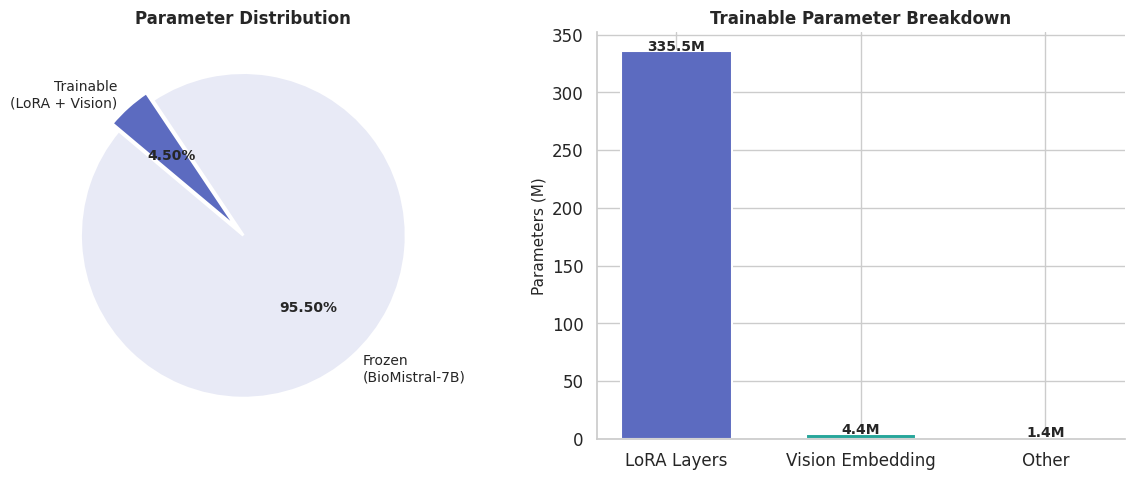

(Plot also saved as param_breakdown.png)


In [42]:
# Visualize the trainable vs frozen parameter ratio
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)

# Pie chart: overall ratio
frozen = total - trainable
labels = ["Frozen\n(BioMistral-7B)", "Trainable\n(LoRA + Vision)"]
sizes = [frozen, trainable]
pie_colors = ["#E8EAF6", "#5C6BC0"]
explode = (0, 0.06)

wedges, texts, autotexts = axes[0].pie(
    sizes, labels=labels, colors=pie_colors, autopct="%1.2f%%",
    startangle=140, explode=explode, textprops={"fontsize": 10},
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
for at in autotexts:
    at.set_fontweight("bold")
axes[0].set_title("Parameter Distribution", fontweight="bold", fontsize=12)

# Bar chart: trainable module breakdown (uses variables from the cell above)
bar_labels = ["LoRA Layers", "Vision Embedding", "LM Head", "Other"]
bar_values = [lora_params / 1e6, vision_params / 1e6, lm_head_params / 1e6, other_trainable / 1e6]
bar_colors = ["#5C6BC0", "#26A69A", "#FFA726", "#EF5350"]

# Filter out zero-value bars for cleaner display
filtered = [(l, v, c) for l, v, c in zip(bar_labels, bar_values, bar_colors) if v > 0.01]
bar_labels, bar_values, bar_colors = zip(*filtered) if filtered else ([], [], [])

bars = axes[1].bar(bar_labels, bar_values, color=bar_colors,
                   edgecolor="white", linewidth=1.5, width=0.6)
axes[1].set_ylabel("Parameters (M)", fontsize=11)
axes[1].set_title("Trainable Parameter Breakdown", fontweight="bold", fontsize=12)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

for bar, v in zip(bars, bar_values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 f"{v:.1f}M", ha="center", fontweight="bold", fontsize=10)

plt.tight_layout()
plt.savefig("param_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()
print("(Plot also saved as param_breakdown.png)")

In [45]:
# enable gradient checkpointing to reduce memory usage during training
# This trades compute for memory by recomputing activations during backward pass
model.gradient_checkpointing_enable()
print("Gradient checkpointing enabled.")

Gradient checkpointing enabled.


### 🧩 Architecture Summary

The table below summarizes the VoRA + BioMistral architecture for our experiment:

| Component | Description | Parameters | Trainable? |
|-----------|-------------|------------|------------|
| **BioMistral-7B** | 32-layer Mistral Transformer, frozen | ~7B | No |
| **LoRA layers** | Low-rank adapters (r=128) on Q, K, V, O, gate, up, down | 335.54M | Yes |
| **Vision embedding** | Shallow MLP + 2D positional encodings | 4.39M | Yes |
| **Aux distillation heads** | RMSNorm + linear for block-wise ViT alignment | 1.38M | Yes (pre-training only) |
| **lm_head** | Linear projection to vocabulary | ~131M | No (pre-training) / Yes (fine-tuning) |
| | | **Total trainable:** | **341.31M (~4.6%)** |

During **pre-training**, only LoRA + vision embedding + aux heads are trained (~341M parameters). The aux heads are used exclusively for block-wise distillation and are discarded afterwards. During **fine-tuning**, the LoRA layers are merged into BioMistral, and the full model is unfrozen for task-specific adaptation on VQA-RAD.

This two-stage approach directly follows the VoRA training protocol ([Wang et al., 2025](https://arxiv.org/abs/2503.20680), Sec. 5.1): pre-train with frozen LLM + trainable LoRA, then merge and fine-tune the full model.

In [46]:
# Quick look at the model structure (first few lines)
# This shows the nesting: VoRAForCausalLM -> llm (MistralForCausalLM) -> model -> layers
model_str = str(model)
#
lines = model_str.split("\n")
for line in lines[:80]:
    print(line)
if len(lines) > 80:
    print(f"\n... ({len(lines) - 80} more lines, truncated for readability)")

VoRAForCausalLM(
  (llm): MistralForCausalLM(
    (model): MistralModel(
      (embed_tokens): Embedding(32001, 4096)
      (layers): ModuleList(
        (0-31): 32 x MistralDecoderLayer(
          (self_attn): MistralAttention(
            (q_proj): LoRALayer(
              in_features=4096, out_features=4096, bias=True
              (lora_A): Linear(in_features=4096, out_features=128, bias=False)
              (lora_B): Linear(in_features=128, out_features=4096, bias=False)
            )
            (k_proj): LoRALayer(
              in_features=4096, out_features=1024, bias=True
              (lora_A): Linear(in_features=4096, out_features=128, bias=False)
              (lora_B): Linear(in_features=128, out_features=1024, bias=False)
            )
            (v_proj): LoRALayer(
              in_features=4096, out_features=1024, bias=True
              (lora_A): Linear(in_features=4096, out_features=128, bias=False)
              (lora_B): Linear(in_features=128, out_features=1024,

### 👁️ Inspecting a Single LoRA-Augmented Layer

Let's zoom into one Transformer layer to see how VoRA attaches LoRA matrices. Each target module (e.g., `self_attn.q_proj`) now has `lora_A` and `lora_B` weight matrices alongside the original frozen `weight`. The output is computed as:

$$\mathbf{y} = \mathbf{W}_{\text{frozen}} \mathbf{x} + \frac{\alpha}{r} \mathbf{B} \mathbf{A} \mathbf{x}$$

where $\mathbf{A} \in \mathbb{R}^{r \times d_{\text{in}}}$ and $\mathbf{B} \in \mathbb{R}^{d_{\text{out}} \times r}$ are the low-rank trainable matrices, and $r$ is the LoRA rank ([Hu et al., 2022](https://arxiv.org/abs/2106.09685)).

In [47]:
# Inspect the first Transformer layer to see LoRA structure
layer_0 = model.llm.model.layers[0]
print("Layer 0 structure:")
print(layer_0)
print("\n" + "=" * 60)

# Check if LoRA weights are present in q_proj
q_proj = layer_0.self_attn.q_proj
print(f"\nq_proj type: {type(q_proj).__name__}")
print(f"Has lora_A: {hasattr(q_proj, 'lora_A')}")
print(f"Has lora_B: {hasattr(q_proj, 'lora_B')}")

if hasattr(q_proj, 'lora_A'):
    print(f"\nlora_A shape: {q_proj.lora_A.weight.shape}")
    print(f"lora_B shape: {q_proj.lora_B.weight.shape}")
    print(f"lora_A requires_grad: {q_proj.lora_A.weight.requires_grad}")
    print(f"lora_B requires_grad: {q_proj.lora_B.weight.requires_grad}")
    print(f"Base weight requires_grad: {q_proj.weight.requires_grad}")

Layer 0 structure:
MistralDecoderLayer(
  (self_attn): MistralAttention(
    (q_proj): LoRALayer(
      in_features=4096, out_features=4096, bias=True
      (lora_A): Linear(in_features=4096, out_features=128, bias=False)
      (lora_B): Linear(in_features=128, out_features=4096, bias=False)
    )
    (k_proj): LoRALayer(
      in_features=4096, out_features=1024, bias=True
      (lora_A): Linear(in_features=4096, out_features=128, bias=False)
      (lora_B): Linear(in_features=128, out_features=1024, bias=False)
    )
    (v_proj): LoRALayer(
      in_features=4096, out_features=1024, bias=True
      (lora_A): Linear(in_features=4096, out_features=128, bias=False)
      (lora_B): Linear(in_features=128, out_features=1024, bias=False)
    )
    (o_proj): LoRALayer(
      in_features=4096, out_features=4096, bias=True
      (lora_A): Linear(in_features=4096, out_features=128, bias=False)
      (lora_B): Linear(in_features=128, out_features=4096, bias=False)
    )
  )
  (mlp): MistralMLP



---



---



# Benchmarking and Expected Performance
Finally, let's discuss how our BioMistral-7B + VoRA model performed compared to other
multimodal medical models, using metrics from their papers:

* LLaVA-Med (Mistral-7B) – This model was instruction-tuned on a large biomedical image-text
set. After fine-tuning on specific VQA datasets, it achieved 84.2% open and 83.1% closed
accuracy on VQA-RAD , and 86.8% open / 91.2% closed on SLAKE , surpassing previous
state-of-the-art. It particularly shined on closed (binary) questions in VQA-RAD and PathVQA,
outperforming all earlier methods . The authors note it set new SOTA on VQA-RAD and
PathVQA closed questions, and on SLAKE open questions . These numbers indicate that a
strong multimodal 7B model can exceed 80% accuracy on these benchmarks, with closed
questions often easier (yes/no questions can reach ~90%+ accuracy ).


* PMC-VQA (MedVInT model) – This approach leveraged a huge 227k QA dataset for pretraining
. Fine-tuned on VQA-RAD and others, it significantly outperformed prior models. For instance,
PMC-VQA’s best model reported around 81.2% overall accuracy on VQA-RAD and 82.0% on
SLAKE in their leaderboard (some figures from their literature: previous SOTA was ~79%
overall on VQA-RAD , which their model exceeded). The exact metrics vary by question type,
but qualitatively, PMC-VQA/MedVInT improved free-form answer quality by aligning a vision
encoder with a LLM.

* Other models: Earlier approaches like M2I2 or Q2ATransformer often treated VQA as
classification and had accuracies in the 70-80% range on these datasets . For example, one
method achieved ~79.2% on VQA-RAD open questions . But those often cannot generate freeform
answers outside of the training answer set. Our approach, being generative, can produce
open-ended answers and should be compared on metrics like BLEU or recall (the VoRA paper
might report “recall” for open answers , meaning the model’s answer contains the groundtruth
phrase).

In conclusion, this implementation is a demonstration how to turn BioMistral-7B into a multimodal
VQA model using VoRA. We detailed the coding steps to attach visual LoRA adapters, recommended the
VQA-RAD dataset (with 1735 chest radiographs and curated QA pairs) for fine-tuning, and provided a
minimal inference example. With sufficient training, the resulting model should be capable of
answering questions about chest X-rays with accuracy on par with state-of-the-art medical VQA models
(approaching or exceeding 80% overall accuracy on benchmarks) , while benefiting from
BioMistral’s in domain knowledge and VoRA’s efficient architecture.

# References
BioMistral/BioMistral-7B · Hugging Face
https://huggingface.co/BioMistral/BioMistral-7B

[2503.20680] Vision as LoRA
https://arxiv.org/abs/2503.20680


VoRA (Vision as LoRA) introduces a novel approach to integrating visual understanding
into Large Language Models by embedding vision directly through Low-Rank Adaptation (LoRA) layers.
| Aleef Mahmud
https://www.linkedin.com/posts/aleefmahmud_vision-as-lora-vora-activity-7336790456988536833-CESH


flaviagiammarino/vqa-rad · Datasets at Hugging Face
https://huggingface.co/datasets/flaviagiammarino/vqa-rad


GitHub - Hon-Wong/VoRA: [Fully open] [Encoder-free MLLM] Vision as LoRA
https://github.com/Hon-Wong/VoRA


[2306.00890] LLaVA-Med: Training a Large Language-and-Vision
Assistant for Biomedicine in One Day
https://ar5iv.labs.arxiv.org/html/2306.00890


[2305.10415] PMC-VQA: Visual Instruction Tuning for Medical Visual Question Answering
https://arxiv.org/abs/2305.10415


config.json · BioMistral/BioMistral-7B at main
https://huggingface.co/BioMistral/BioMistral-7B/blob/main/config.


config.json · Hon-Wong/VoRA-7B-Base at main
https://huggingface.co/Hon-Wong/VoRA-7B-Base/blob/main/config.json


Hon-Wong/VoRA-7B-Instruct · Hugging Face
https://huggingface.co/Hon-Wong/VoRA-7B-Instruct
